In [1]:
import os
import sys
import pprint
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
notebook_name = os.path.basename(os.getcwd())
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '..')))
# Import the reusable fit helper and confirm availability
from pySASfit.io_tools.fit_helpers import fit_stack, read_files_sumtof
print('fit_stack imported from', fit_stack.__module__)
# Short doc preview:
print((fit_stack.__doc__ or '')[:400])

fit_stack imported from pySASfit.io_tools.fit_helpers
Fit a stack of SUMtof arrays using the triangular model.

    Parameters
    - sum_tofs: iterable of 1D arrays (n_files x ntof)
    - labels: iterable of names (same length as sum_tofs)
    - tof: optional x-axis array matching each y's length; if None, index axis used
    - L: optional flight path length used to compute lambda; if None, lambda may be
         calculated from `other_centers` if pr


C:\Users\kohlbrecher\switchdrive\pySASfit\io_tools\fit_triangle.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


          center     width    rpm    lambda  lambda_err      DL/L  DL/L_err  \
name                                                                          
12000  22.186836  4.235765  12000  1.097148    0.000201  0.095457  0.000373   
14000  19.032852  3.627968  14000  0.941183    0.000142  0.095308  0.000298   
16000  16.658437  3.161242  16000  0.823767    0.000114  0.094884  0.000281   
18000  14.823447  2.814392  18000  0.733026    0.000095  0.094930  0.000266   
20000  13.351745  2.533770  20000  0.660249    0.000085  0.094885  0.000262   
22000  12.152175  2.318543  22000  0.600930    0.000064  0.095396  0.000214   
24000  11.149355  2.141577  24000  0.551340    0.000053  0.096040  0.000193   
25000  10.304912  1.958094  26000  0.509582    0.000058  0.095008  0.000239   
28000   9.584779  1.840899  28000  0.473971    0.000061  0.096032  0.000248   

         SD  
name         
12000  8000  
14000  8000  
16000  8000  
18000  8000  
20000  8000  
22000  8000  
24000  8000  
2500

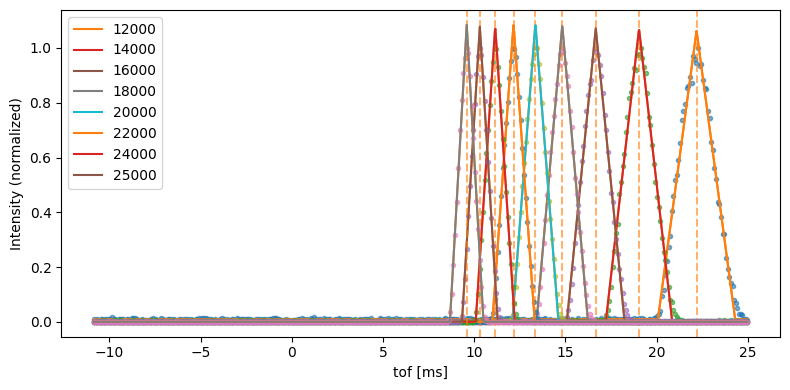

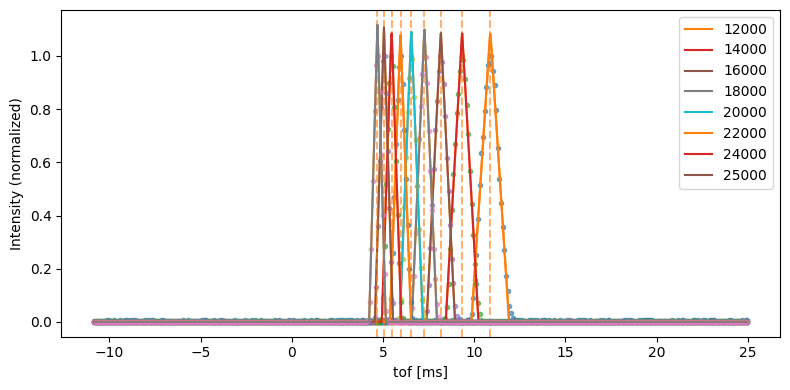

In [27]:
# pattern matching your files
Data_path="C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF"
pattern = os.path.join(Data_path, "sans2025n08931*.hdf")
file_list = sorted(glob.glob(pattern))
if not file_list:
    raise RuntimeError(f"No files matched {pattern}")
#pprint.pp(file_list)
# optional: keep only the files you expect (e.g. indices 2..9)
# file_list = [f for f in file_list if re.search(r"08931[2-9]\.hdf$", f)]



tof8_files=(
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089312.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089313.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089314.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089315.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089316.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089317.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089318.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089319.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089320.hdf",
)
tof4_files=(
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089321.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089322.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089323.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089324.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089325.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089326.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089327.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089328.hdf",
    "C:/Users/kohlbrecher/switchdrive/SANS/user/NVS_TOF/sans2025n089329.hdf",
)
sum8_tofs = read_files_sumtof(tof8_files)
sum4_tofs = read_files_sumtof(tof4_files)
labels8=(
    "12000",
    "14000",
    "16000",
    "18000",
    "20000",
    "22000",
    "24000",
    "25000",
    "28000",
)
labels4=labels8

#pprint.pp(sum8_tofs)
# The fitting logic is centralized in `fit_stack` (imported above).
# Re-run the fits (no plotting by default) and show result tables.
# Prefer passing `tof` explicitly to avoid globals() lookups if available.
tof = (np.arange(0, 399, dtype=float) * 900.0e-4) - 10.85
results8 = fit_stack(sum8_tofs, labels8, tof=tof if 'tof' in globals() else None, L=8000, rpm_start=12000, rpm_step=2000, plot=True)
results4 = fit_stack(sum4_tofs, labels4, tof=tof if 'tof' in globals() else None, L=None, rpm_start=12000, rpm_step=2000, plot=True,other_centers=[r['center'] for r in results8])

df = pd.DataFrame(results8).set_index('name')
print(df)
print("\n")
df = pd.DataFrame(results4).set_index('name')
print(df)
print("\n")